# Atlético Madrid — Griezmann Replacement Candidate Analysis
*Recruitment Analytics | Top 5 European Leagues | 2024/25 & 2025/26*

### Business Problem
Atletico Madrid is losing Antoine Griezmann, arguably their best player for the last decade, at the end of the current 2025/26 season. Beyond an emotional void, his departure causes a disruption in the current Atletico Madrid playing structure. Aside from goal scoring, Griezmann's second phase at the club saw him have a slightly different role; age and differing player profiles at the club all contributed to this. Griezmann became more of the connective tissue of Simeone's system - adopting a more free-roaming number 10 / 8 role who linked midfield to attack, pressed opponents, and created chances. Finding a direct replacement is not straightforward, especially for someone of his ability, but also because of his unique, versatile profile. Griezmann was never a pure goal scorer or a pure creator; he fell into every category, which is what made Atletico Madrid function.


### Aim
Use 2024/25 and 2025/26 football data to build a data-driven candidate shortlist of players who most closely replicate Griezmann's statistical profile across the top 5 European leagues - delivering Atletico Madrid's recruitment scouting department with an evidence-based shortlist for possible replacement in the upcoming 2026 summer window.

### Why This Matters in Football
Modern football clubs increasingly rely on data to identify transfer targets before committing significant resources. Recruitment analytics reduces the risk of expensive mistakes by surfacing statistically similar players who may be overlooked by traditional scouting. This analysis demonstrates how cosine similarity modeling and percentile profiling can translate raw match data into actionable recruitment intelligence.


## Notebook Purpose
This notebook contains the deep-dive candidate analysis for the final shortlist identified in `griezmann_profile.ipynb`. Each candidate is profiled using composite and detailed radar charts overlaid against Griezmann's 2024/25 benchmark, with final recommendations 
made combining statistical findings and football context.

In [ ]:
import matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mplsoccer import Radar
from scipy.stats import percentileofscore
from matplotlib.patches import Patch 
import warnings
warnings.filterwarnings('ignore')



In [20]:
# 24/25 full dataset for stats
df_2425 = pd.read_csv("players_data-2024_2025.csv")

# Griezmann percentiles already calculated from previous notebook
griez_percentiles_df = pd.read_csv("griezmann_percentiles_2425.csv")

# Final shortlist from previous notebook
final_shortlist_df = pd.read_csv("final_shortlist_2425.csv")

print(f"24/25 dataset: {df_2425.shape}")
print(f"Shortlist players: {final_shortlist_df['Player'].tolist()}")

24/25 dataset: (2854, 267)
Shortlist players: ['Franck Honorat', 'Phil Foden', 'Fares Chaïbi', 'Alex Baena', 'Bryan Mbeumo', 'Lee Kang-in', 'Julian Brandt', 'Matìas Soulé']


## Candidate Percentile Profiling
Each shortlisted player's per90 stats are converted to percentile ranks against the same FW/MF candidate pool used to profile Griezmann in the profiling notebook. Composite scores 
are then calculated across five footballing categories for radar comparison.

All percentile ranks are relative to forwards and midfielders across the top 5 European leagues with a minimum of 900 minutes played in 2024/25.

In [21]:
# Full candidate pool to calculate percentiles against
candidates_2425 = df_2425[
    (df_2425['Min'] >= 900) &
    (df_2425['Age'] <= 30) &
    (df_2425['Pos'].str.contains('FW|MF', case=False, na=False))
].copy()

numeric_cols = ['Gls', 'Ast', 'npxG', 'xAG', 'Sh', 'SoT', 'SoT%',
                'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'PrgP', 'PrgC', 'PrgR',
                'KP', 'PPA', 'SCA', 'TklW', 'Int', 'Att 3rd', 'Fld', 'Crs']

candidates_2425[numeric_cols] = candidates_2425[numeric_cols].apply(pd.to_numeric, errors='coerce')

candidates_2425['Gls/90'] = candidates_2425['Gls']/candidates_2425['90s']
candidates_2425['Ast/90'] = candidates_2425['Ast']/candidates_2425['90s']
candidates_2425['npxG/90'] = candidates_2425['npxG']/candidates_2425['90s']
candidates_2425['xAG/90'] = candidates_2425['xAG']/candidates_2425['90s']
candidates_2425['PrgP/90'] = candidates_2425['PrgP']/candidates_2425['90s']
candidates_2425['PrgC/90'] = candidates_2425['PrgC']/candidates_2425['90s']
candidates_2425['PrgR/90'] = candidates_2425['PrgR']/candidates_2425['90s']
candidates_2425['KP/90'] = candidates_2425['KP']/candidates_2425['90s']
candidates_2425['PPA/90'] = candidates_2425['PPA']/candidates_2425['90s']
candidates_2425['SCA/90'] = candidates_2425['SCA']/candidates_2425['90s']
candidates_2425['TklW/90'] = candidates_2425['TklW']/candidates_2425['90s']
candidates_2425['Int/90'] = candidates_2425['Int']/candidates_2425['90s']
candidates_2425['Fld/90'] = candidates_2425['Fld']/candidates_2425['90s']
candidates_2425['Crs/90'] = candidates_2425['Crs']/candidates_2425['90s']
candidates_2425['Att3rd/90'] = candidates_2425['Att 3rd']/candidates_2425['90s']

candidates_2425 = candidates_2425.dropna(subset=['npxG/90', 'xAG/90']).copy()

print(f"Candidate pool: {candidates_2425.shape[0]} players")

Candidate pool: 826 players


In [22]:
def get_player_percentiles(player_name, candidate_pool):
    # Pull player row — keep highest minutes if duplicate
    player_row = candidate_pool[
        candidate_pool['Player'].str.contains(player_name, case=False, na=False)
    ].sort_values('Min', ascending=False).head(1)
    
    if player_row.empty:
        print(f"Player not found: {player_name}")
        return None
    
    features = ['Gls/90', 'Ast/90', 'npxG/90', 'xAG/90',
                'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'SoT%',
                'PrgP/90', 'PrgC/90', 'PrgR/90',
                'KP/90', 'PPA/90', 'SCA/90',
                'TklW/90', 'Int/90', 'Fld/90',
                'Crs/90', 'Att3rd/90']
    
    percentiles = {}
    for f in features:
        val = player_row[f].values[0]
        all_vals = candidate_pool[f].dropna().values
        percentiles[f] = round(percentileofscore(all_vals, val), 1)
    
    # Composite scores
    composites = {
        'Goal Threat': np.mean([percentiles['Gls/90'], percentiles['npxG/90'], percentiles['Sh/90'], percentiles['SoT/90']]),
        'Finishing Quality': np.mean([percentiles['G/Sh'], percentiles['G/SoT'], percentiles['SoT%']]),
        'Chance Creation': np.mean([percentiles['Ast/90'], percentiles['xAG/90'], percentiles['KP/90'], percentiles['PPA/90'], percentiles['SCA/90'], percentiles['Crs/90']]),
        'Ball Progression': np.mean([percentiles['PrgP/90'], percentiles['PrgC/90'], percentiles['PrgR/90']]),
        'Defensive Contribution': np.mean([percentiles['TklW/90'], percentiles['Int/90'], percentiles['Att3rd/90'], percentiles['Fld/90']]),
    }
    squad = player_row['Squad'].values[0]
    age = player_row['Age'].values[0]
    mins = player_row['Min'].values[0]
    
    print(f"{player_name} | {squad} | Age: {age} | Min: {mins}")
    for k, v in composites.items():
        print(f"  {k}: {v:.1f}")
    
    return composites


In [23]:
players = [
    'Honorat', 'Foden', 'Chaïbi', 'Baena',
    'Mbeumo', 'Kang-in', 'Brandt', 'Soulé'
]

all_composites = {}
for player in players:
    print(f"\n{player}:")
    result = get_player_percentiles(player, candidates_2425)
    if result:
        all_composites[player] = result




Honorat:
Honorat | Gladbach | Age: 27.0 | Min: 1439
  Goal Threat: 67.1
  Finishing Quality: 62.8
  Chance Creation: 96.8
  Ball Progression: 70.0
  Defensive Contribution: 20.2

Foden:
Foden | Manchester City | Age: 24.0 | Min: 1777
  Goal Threat: 80.6
  Finishing Quality: 63.4
  Chance Creation: 84.1
  Ball Progression: 76.4
  Defensive Contribution: 35.5

Chaïbi:
Chaïbi | Eint Frankfurt | Age: 21.0 | Min: 1013
  Goal Threat: 58.8
  Finishing Quality: 22.5
  Chance Creation: 91.6
  Ball Progression: 66.2
  Defensive Contribution: 56.1

Baena:
Baena | Villarreal | Age: 23.0 | Min: 2595
  Goal Threat: 69.4
  Finishing Quality: 51.6
  Chance Creation: 98.1
  Ball Progression: 78.7
  Defensive Contribution: 49.2

Mbeumo:
Mbeumo | Brentford | Age: 24.0 | Min: 3414
  Goal Threat: 76.8
  Finishing Quality: 85.1
  Chance Creation: 85.1
  Ball Progression: 78.2
  Defensive Contribution: 50.4

Kang-in:
Kang-in | Paris S-G | Age: 23.0 | Min: 1663
  Goal Threat: 72.1
  Finishing Quality: 71.2
 

## Composite Radar Comparison — All 8 Candidates vs Griezmann
Five-axis composite radars overlaid against Griezmann's 2024/25 benchmark profile. 
Red shape represents Griezmann, blue represents the candidate. Each axis is a composite of related per90 metrics grouped into footballing categories.

Griezmann's composite scores for reference:
- Goal Threat: 63.9
- Finishing Quality: 71.6
- Chance Creation: 86.4
- Ball Progression: 67.7
- Defensive Contribution: 23.7

In [ ]:
griez_composites = {
    'Goal Threat'            : 63.9,
    'Finishing Quality'      : 71.6,
    'Chance Creation'        : 86.4,
    'Ball Progression'       : 67.7,
    'Defensive Contribution' : 23.7,
}

labels = [
        'Goal Threat',
        'Finishing Quality',
        'Chance Creation',
        'Ball Progression',
        'Defensive Contribution'
    ]

def draw_comparison_radar(player_name, player_composites, griez_composites, save=True):

    
    griez_values = [griez_composites[l] for l in labels]
    player_values = [player_composites[l] for l in labels]
    
    low  = [0] * 5
    high = [100] * 5
    
    radar = Radar(labels, low, high, num_rings=4, ring_width=1, center_circle_radius=1)
    
    fig, ax = radar.setup_axis(figsize=(8, 8))
    fig.patch.set_facecolor('#0c0c0e')
    ax.set_facecolor('#0c0c0e')
    
    # Background rings
    radar.draw_circles(ax=ax, facecolor='#070707', edgecolor='#444444',
                       linewidth=1.5, linestyle='--')
    
    # Griezmann shape — red
    radar.draw_radar(griez_values, ax=ax,
                     kwargs_radar={'facecolor': '#c8102e', 'alpha': 0.3},
                     kwargs_rings={'facecolor': '#0c0c0e', 'alpha': 0})
    
    # Candidate shape — blue
    radar.draw_radar(player_values, ax=ax,
                     kwargs_radar={'facecolor': '#1d70b8', 'alpha': 0.5},
                     kwargs_rings={'facecolor': '#0c0c0e', 'alpha': 0})
    
    radar.draw_param_labels(ax=ax, fontsize=11, color='white')
    radar.draw_range_labels(ax=ax, fontsize=8, color='#BCBCBC')
    
    # Legend
    #from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#c8102e', alpha=0.5, label='Griezmann 2024/25'),
        Patch(facecolor='#1d70b8', alpha=0.7, label=player_name)
    ]
    ax.legend(handles=legend_elements, loc='upper right',
              facecolor='#0c0c0e', edgecolor='#444444',
              labelcolor='white', fontsize=9)
    
    ax.set_title(f'{player_name} vs Griezmann — Composite Profile\n2024/25 Season | Percentile Ranks vs FW/MF Pool',
                 fontsize=13, fontweight='bold', color='white', pad=20)
    
    plt.tight_layout()
    
    if save:
        filename = f"radar_{player_name.replace(' ', '_').lower()}.png"
        plt.savefig(filename, dpi=150, bbox_inches='tight', facecolor='#0c0c0e')
        print(f"Saved: {filename}")

    plt.show()

Saved: radar_honorat.png


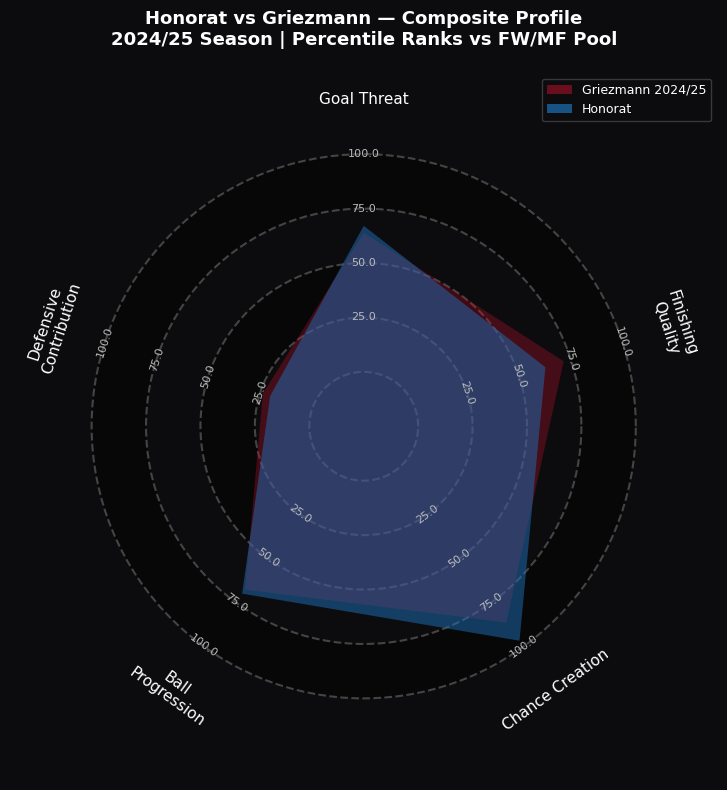

Saved: radar_foden.png


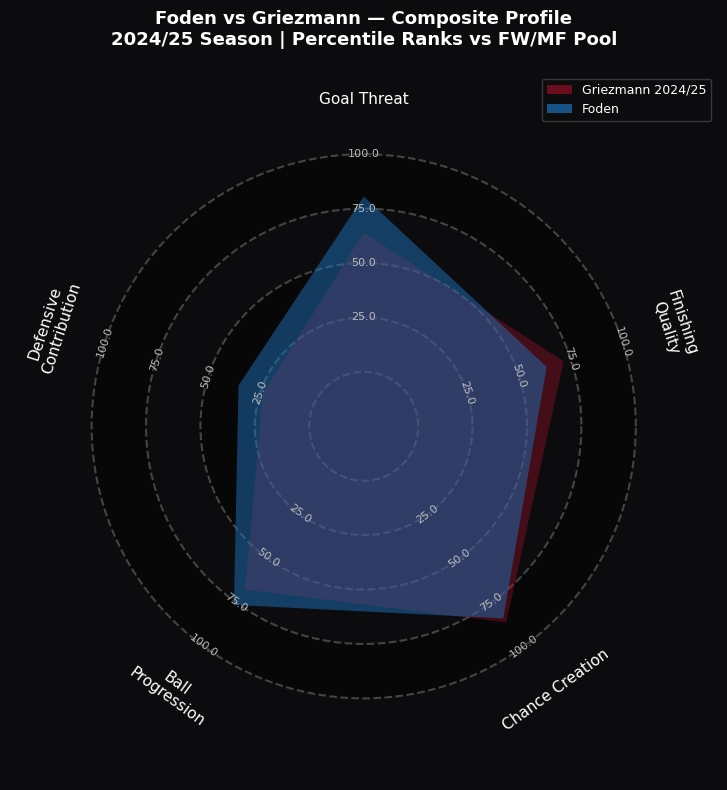

Saved: radar_chaïbi.png


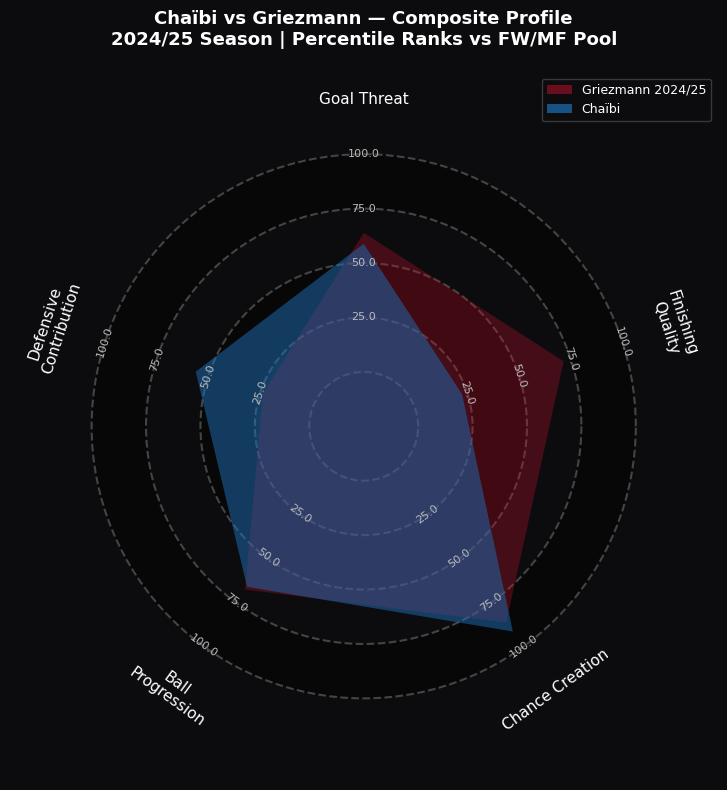

Saved: radar_baena.png


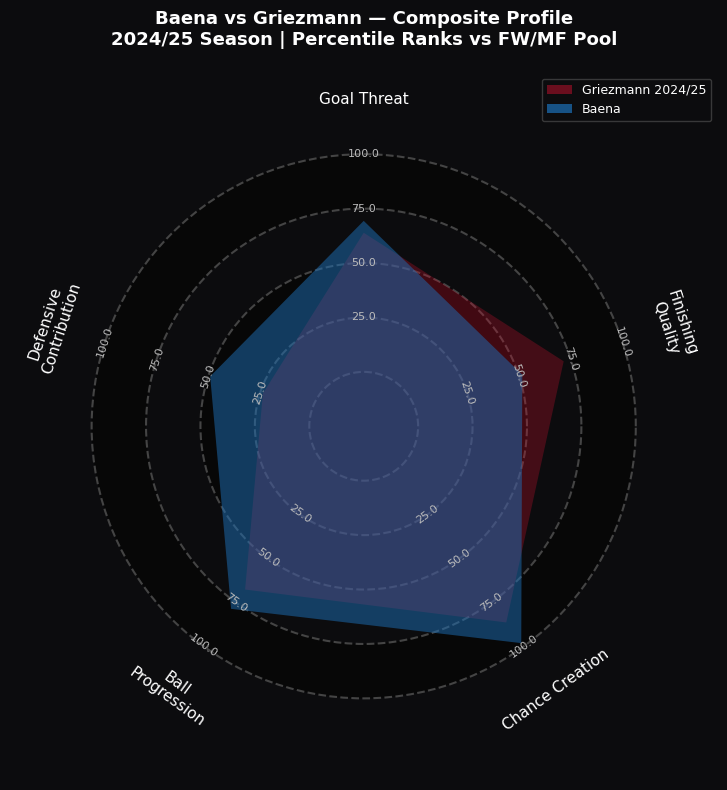

Saved: radar_mbeumo.png


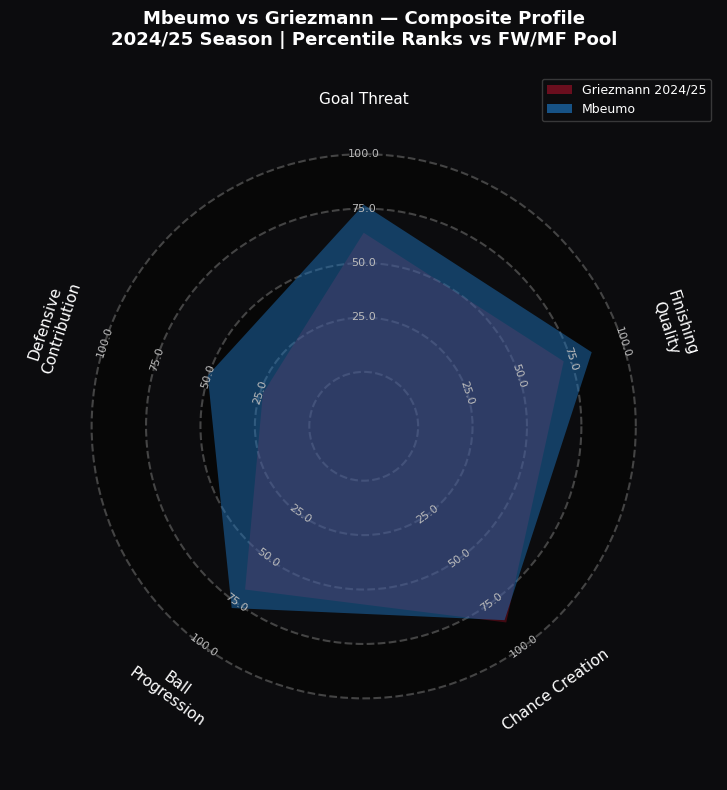

Saved: radar_kang-in.png


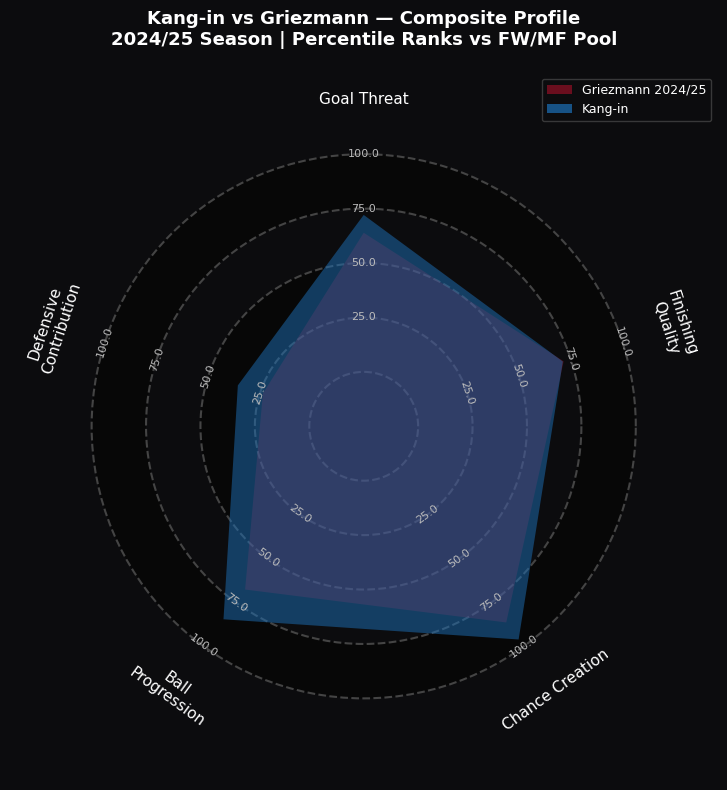

Saved: radar_brandt.png


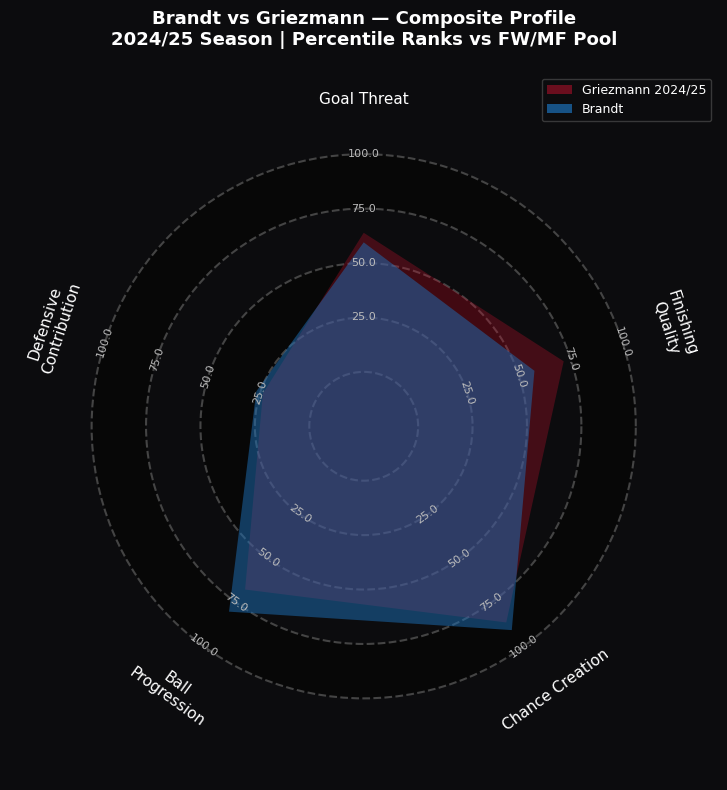

Saved: radar_soulé.png


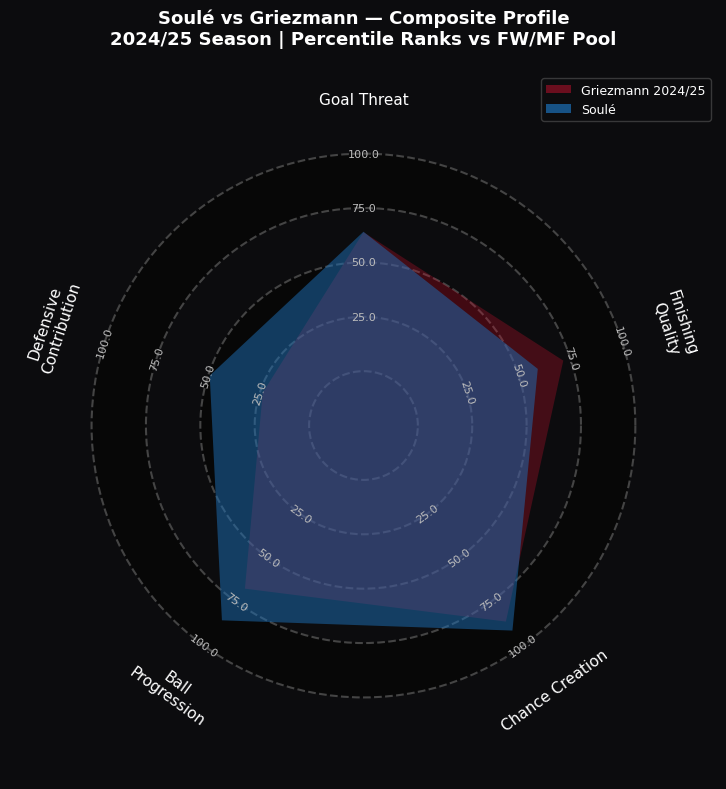

In [25]:
for player_name, composites in all_composites.items():
    draw_comparison_radar(player_name, composites, griez_composites)

## Candidate Refinement - Football Context Applied
Following the composite radar analysis, the shortlist is refined using football context and transfer realism alongside the statistical findings:

**Removed:**
- **Bryan Mbeumo** - recently joined Manchester United, departure unrealistic within one season
- **Franck Honorat** — data profile is strong but at age 29 and turning 30 during the summer, realism of being a fit for a club prioritizing younger additions over the last recent windows
- **Fares Chaïbi** — profiled as a fulcrum midfielder at Eintracht Frankfurt, interesting profile and strong pressing numbers but not yet at the star level Atlético requires for a Griezmann succession role as of now
- **Julian Brandt** — available on a free transfer with Champions League experience, however at age 29 and turning 30 raises questions about whether he represents a genuine replacement or a short term stop-gap. Atlético's recent 
transfer philosophy prioritizes younger players with promising ceilings.

**Final Four:**
- **Lee Kang-in** — closest statistical profile to Griezmann, genuine transfer interest
- **Alex Baena** — already at Atlético, data suggests the replacement is already at home
- **Matías Soulé** — young upside pick, shows strong ball progression and chance creation
- **Phil Foden** — the ambitious hidden gem, similar situation Julian Alvarez faced at city with inconsistent starts

## Final Four — Detailed 20-Metric Radar Comparison
Following football context filtering, the four final candidates are selected for deeper analysis and detailed radars plotted visualize a more in depth comparison to Griezmann's profile - revealing specific areas of strength, similarity and gap for each player.

In [26]:
def get_player_detailed_percentiles(player_name, candidate_pool):
    
    player_row = candidate_pool[
        candidate_pool['Player'].str.contains(player_name, case=False, na=False)
    ].sort_values('Min', ascending=False).head(1)
    
    if player_row.empty:
        print(f"Player not found: {player_name}")
        return None
    
    features = ['Gls/90', 'Ast/90', 'npxG/90', 'xAG/90',
                'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'SoT%',
                'PrgP/90', 'PrgC/90', 'PrgR/90',
                'KP/90', 'PPA/90', 'SCA/90',
                'TklW/90', 'Int/90', 'Fld/90',
                'Crs/90', 'Att3rd/90']
    
    percentiles = {}
    for f in features:
        val = player_row[f].values[0]
        all_vals = candidate_pool[f].dropna().values
        percentiles[f] = round(percentileofscore(all_vals, val), 1)
    
    squad = player_row['Squad'].values[0]
    age = player_row['Age'].values[0]
    mins = player_row['Min'].values[0]
    
    print(f"\n{player_name} | {squad} | Age: {age} | Min: {mins}")
    for k, v in percentiles.items():
        print(f"  {k}: {v}")
    
    return percentiles

final_four = ['Kang-in', 'Baena', 'Soulé', 'Foden']

detailed_percentiles = {}
for player in final_four:
    result = get_player_detailed_percentiles(player, candidates_2425)
    if result:
        detailed_percentiles[player] = result


Kang-in | Paris S-G | Age: 23.0 | Min: 1663
  Gls/90: 80.0
  Ast/90: 95.0
  npxG/90: 62.5
  xAG/90: 96.6
  Sh/90: 75.5
  SoT/90: 70.4
  G/Sh: 80.1
  G/SoT: 80.0
  SoT%: 53.5
  PrgP/90: 97.1
  PrgC/90: 74.5
  PrgR/90: 82.2
  KP/90: 99.3
  PPA/90: 96.9
  SCA/90: 97.2
  TklW/90: 50.0
  Int/90: 9.0
  Fld/90: 8.6
  Crs/90: 91.4
  Att3rd/90: 75.6

Baena | Villarreal | Age: 23.0 | Min: 2595
  Gls/90: 68.9
  Ast/90: 94.2
  npxG/90: 69.9
  xAG/90: 99.2
  Sh/90: 80.8
  SoT/90: 57.9
  G/Sh: 55.1
  G/SoT: 76.8
  SoT%: 22.9
  PrgP/90: 92.7
  PrgC/90: 82.0
  PrgR/90: 61.3
  KP/90: 99.8
  PPA/90: 98.3
  SCA/90: 99.0
  TklW/90: 21.0
  Int/90: 64.2
  Fld/90: 57.0
  Crs/90: 98.3
  Att3rd/90: 54.5

Soulé | Roma | Age: 21.0 | Min: 1781
  Gls/90: 69.9
  Ast/90: 87.3
  npxG/90: 53.3
  xAG/90: 92.9
  Sh/90: 70.8
  SoT/90: 62.4
  G/Sh: 66.2
  G/SoT: 70.5
  SoT%: 41.1
  PrgP/90: 72.2
  PrgC/90: 91.6
  PrgR/90: 93.3
  KP/90: 97.7
  PPA/90: 90.6
  SCA/90: 93.1
  TklW/90: 41.2
  Int/90: 38.0
  Fld/90: 46.4
  Crs

In [27]:
radar_features = ['Gls/90', 'npxG/90', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'SoT%',
    'Ast/90', 'xAG/90', 'Crs/90', 
    'KP/90', 'PPA/90', 'SCA/90', 'PrgP/90', 'PrgC/90', 'PrgR/90',
    'TklW/90', 'Int/90', 'Fld/90', 'Att3rd/90']

griez_detailed = {
    'Gls/90': 74.5, 'Ast/90': 87.2, 'npxG/90': 67.6, 'xAG/90': 92.4,
    'Sh/90': 55.5, 'SoT/90': 58.1, 'G/Sh': 79.6, 'G/SoT': 76.6, 'SoT%': 58.5,
    'PrgP/90': 83.9, 'PrgC/90': 47.9, 'PrgR/90': 71.4,
    'KP/90': 81.9, 'PPA/90': 90.4, 'SCA/90': 75.1,
    'TklW/90': 29.0, 'Int/90': 14.2, 'Fld/90': 32.0,
    'Crs/90': 91.5, 'Att3rd/90': 19.5
}

griez_values = [griez_detailed[p] for p in radar_features]



In [ ]:
def draw_detailed_radar(player_name, player_percentiles, save=True):
    
    player_values = [player_percentiles[p] for p in radar_features]
    
    low  = [0] * len(radar_features)
    high = [100] * len(radar_features)
    
    radar = Radar(radar_features, low, high, num_rings=4, ring_width=1, center_circle_radius=1)
    
    fig, ax = radar.setup_axis(figsize=(10, 10))
    fig.patch.set_facecolor('#0c0c0e')
    ax.set_facecolor('#0c0c0e')
    
    radar.draw_circles(ax=ax, facecolor='#070707', edgecolor='#444444',
                       linewidth=1.5, linestyle='--', alpha=1)
    
    # Griezmann — red
    radar.draw_radar(griez_values, ax=ax,
                     kwargs_radar={'facecolor': '#c8102e', 'alpha': 0.3},
                     kwargs_rings={'facecolor': '#1a1a2e', 'alpha': 0})
    
    # Candidate — blue
    radar.draw_radar(player_values, ax=ax,
                     kwargs_radar={'facecolor': '#1d70b8', 'alpha': 0.5},
                     kwargs_rings={'facecolor': '#1a1a2e', 'alpha': 0})
    
    radar.draw_param_labels(ax=ax, fontsize=9, color='white')
    radar.draw_range_labels(ax=ax, fontsize=7, color='#BCBCBC')
    

    legend_elements = [
        Patch(facecolor='#c8102e', alpha=0.5, label='Griezmann 2024/25'),
        Patch(facecolor='#1d70b8', alpha=0.7, label=player_name)
    ]
    ax.legend(handles=legend_elements, loc='upper right',
              facecolor='#0c0c0e', edgecolor='#444444',
              labelcolor='white', fontsize=9)
    
    ax.set_title(f'{player_name} vs Griezmann — Detailed Profile\n2024/25 Season | Percentile Ranks vs FW/MF Pool',
                 fontsize=13, fontweight='bold', color='white', pad=20)
    
    plt.tight_layout()
    
    if save:
        filename = f"radar_detailed_{player_name.replace(' ', '_').lower()}.png"
        plt.savefig(filename, dpi=150, bbox_inches='tight', facecolor='#0c0c0e')
        print(f"Saved: {filename}")

    plt.show()

Saved: radar_detailed_kang-in.png


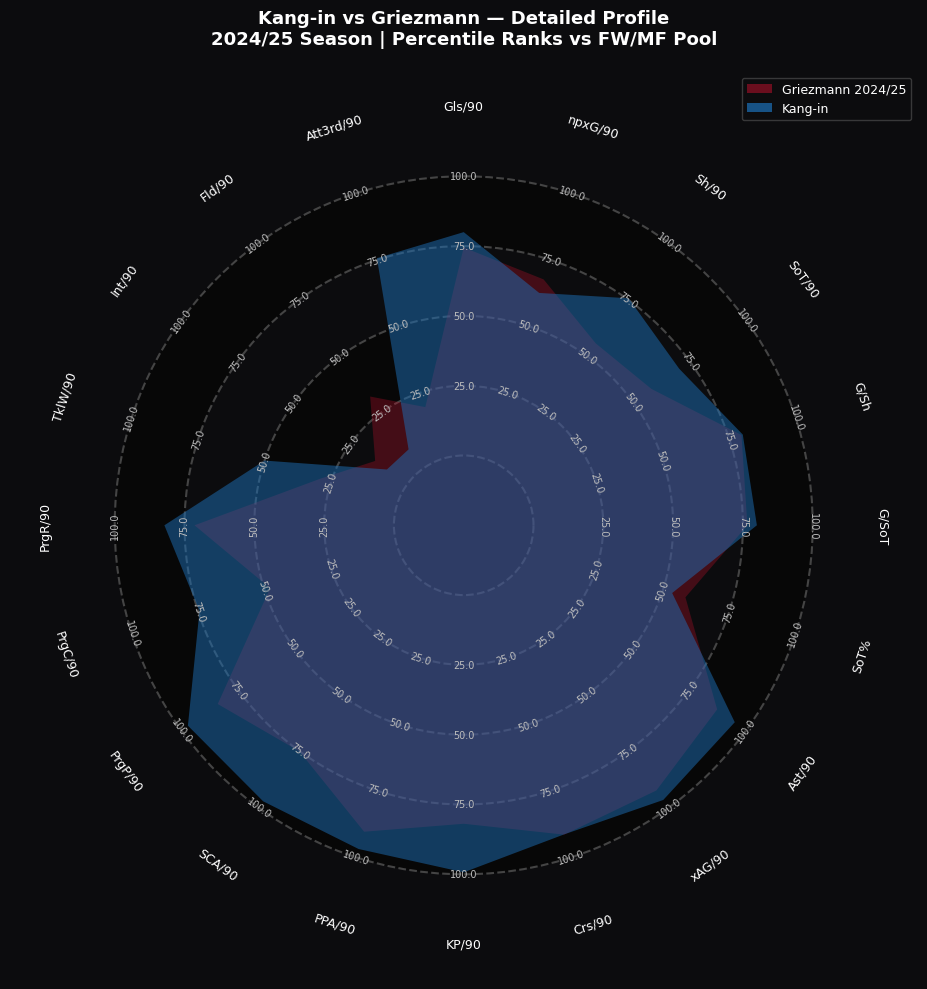

Saved: radar_detailed_baena.png


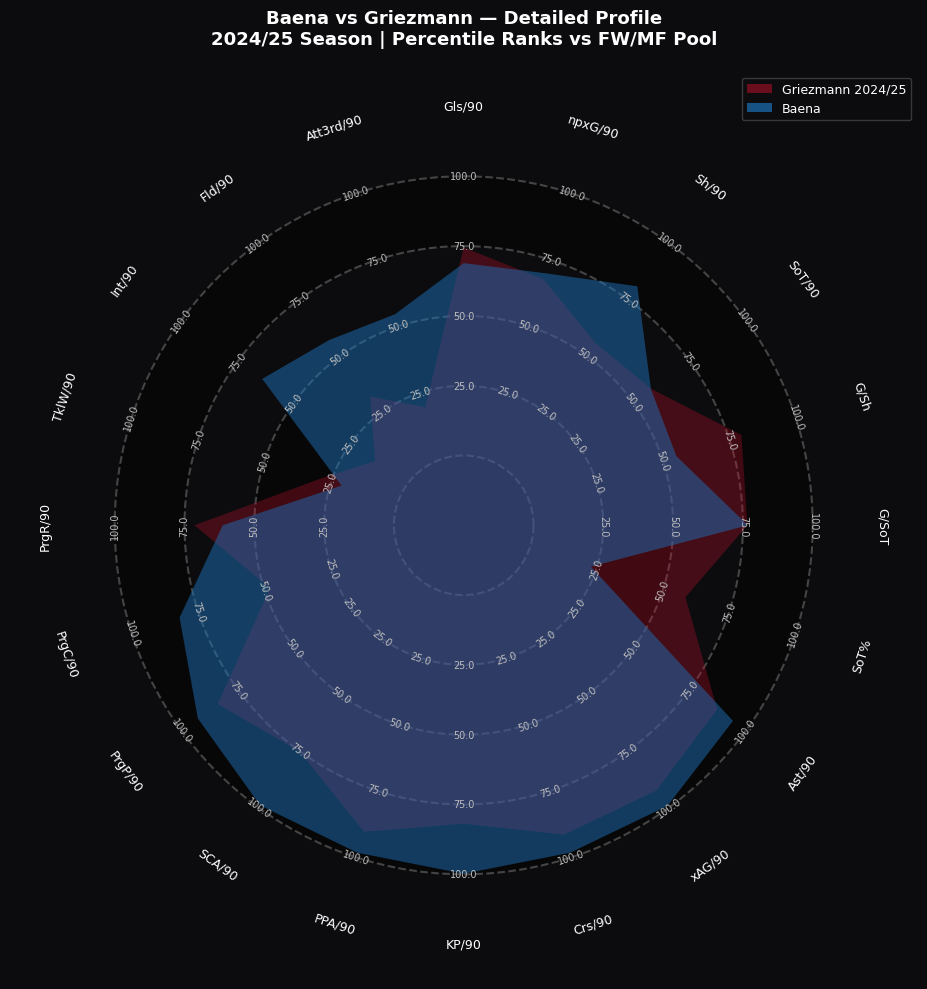

Saved: radar_detailed_soulé.png


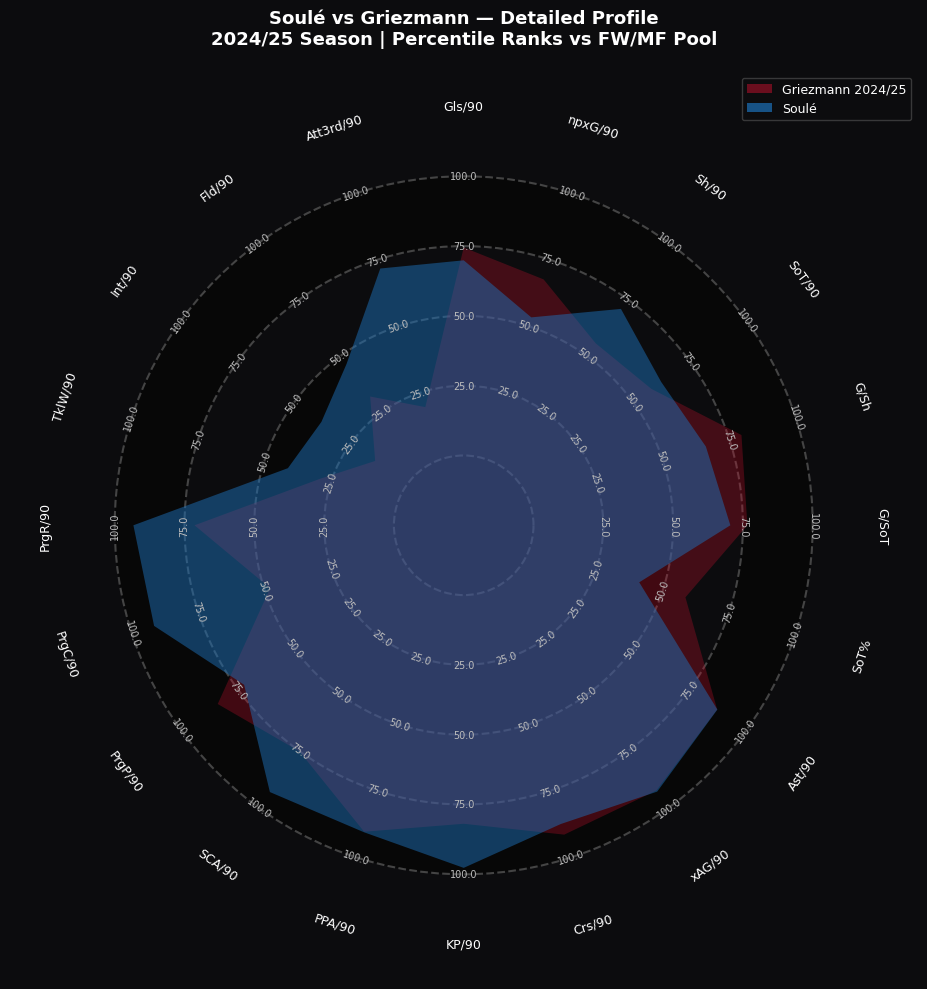

Saved: radar_detailed_foden.png


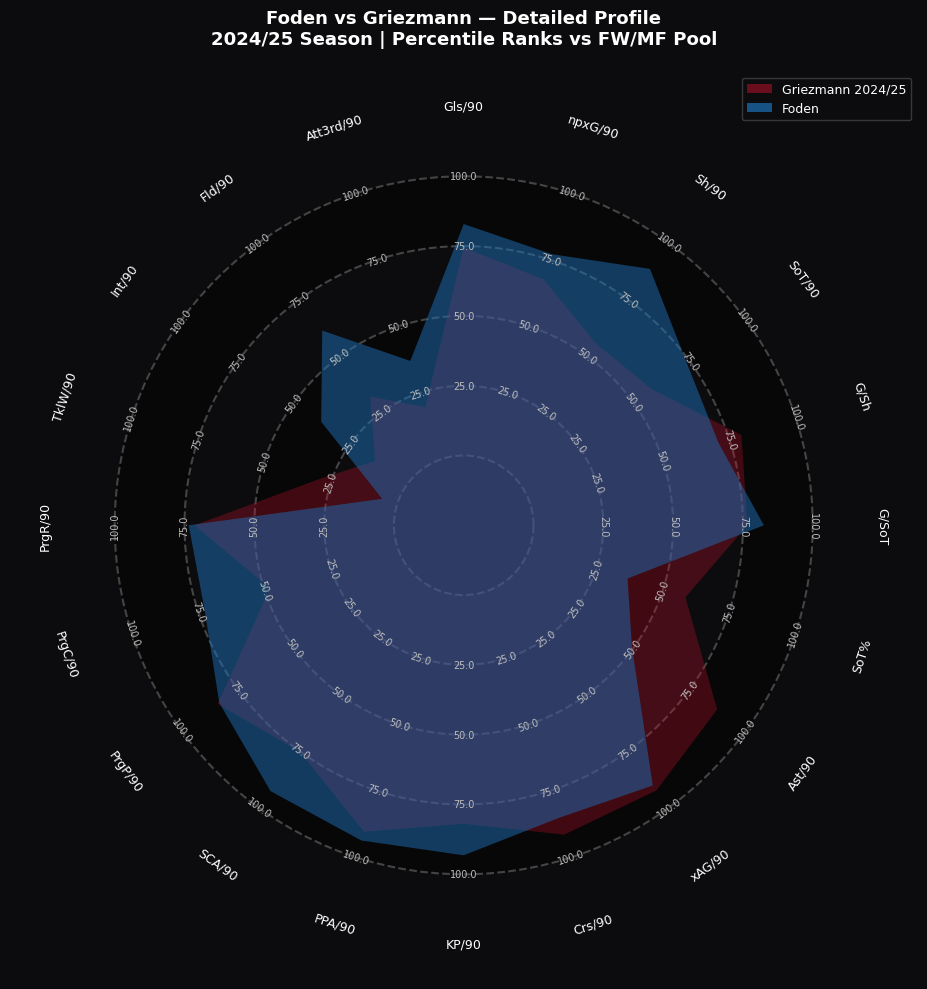

In [29]:
for player_name, percentiles in detailed_percentiles.items():
    draw_detailed_radar(player_name, percentiles)

## Findings & Recommendations

The composite and detailed radar analysis across the final four candidates reveals a clear picture of what is available in the market to replace Antoine Griezmann, and more importantly, what kind of replacement Atlético Madrid should be targeting.

### The Key Finding
No player will be a perfect like-for-like replacement for Griezmann, especially taking into account the two varying versions of Griezmann lived at Atletico Madrid in his 10 season career at the club. His most recent profile - elite chance creation, solid goal threat, good ball progression, and active defensive contributions - is rare to come across in the sport as a whole. However, the analysis was successful at providing a shortlist of players who replicate key areas of his profile at a high level. The following recommendations should be understood as data-backed starting points for replacement discussions, not guarantees as a like-for-like solution.

### Candidate Assessments

**Kang-In Lee — Primary Recommendation**
Statistically, the closest profile match to Griezmann in the dataset. His chance creation 
numbers are exceptional — KP/90, PPA/90, SCA/90, and xAG/90 all rank in the top 1-3% of 
the candidate pool. He receives progressive passes in advanced areas at a rate that mirrors 
Griezmann's movement and his goal threat is genuine without being the dominant 
feature of his game. Transfer links with Atlético already exist, with sporting 
director Alemany reportedly involved in discussions. The defensive contribution gap is not of primary concern when deciding if he's suitable, as given the club's track 
record of integrating defensive discipline to attacking players, this is manageable. 
Age 25 gives Atlético a player who can grow into the role rather than simply fill it.

**Alex Baena — The Replacement is Already at Home**
The most statistically compelling finding of this entire analysis. Baena's chance creation 
profile is the highest of any candidate — KP/90 at 99.8th percentile, SCA/90 at 99th, 
xAG/90 at 99.2, additionally having led chance creation in La Liga in the 2024/25 campaign with 93 total events.
Rather than spending resources in the transfer market, the data makes a strong case for 
giving Baena the keys to the Griezmann role and allowing him to grow into it. His finishing 
efficiency is the one area where he falls short of Griezmann — SoT% at 22.9, compared to Griezmann's 
58.5 — but at age 24, this is an improvable area. The recommendation here is simple: before 
looking externally, trust what is already in the team.

**Matías Soulé — The Young Upside Option**
At 23, Soulé profiles as an elite ball progressor — PrgC/90 at 91.6th percentile, PrgR/90 at 93.3rd — showing an ability 
to carry and receive the ball in dangerous areas that complements the role. Chance 
creation at the 91st-97th percentile range across multiple metrics confirms he is already 
operating at a high level despite his young age. The finishing quality gap relative to Griezmann 
suggests he might not be as involved in the box, but, similar to Baena, it can be added to his game. His ceiling at 23 looks promising and the data 
is already elite in several dimensions. If Atlético are building for the next four to five years, Soulé represents as strong case.

**Phil Foden — The Ambitious Hidden Gem**
Foden is included not as a super-realistic target but as a statistically backed case 
for a bold summer approach. His detailed radar shows the highest goal threat of the four 
finalists — Gls/90 at 82.9th percentile, npxG/90 at 77.1st, Sh/90 at 88.5th — combined 
with elite chance creation across KP/90, PPA/90 and SCA/90. The defensive contribution 
gap is the most significant concern, with TklW/90 at just 5.7th percentile, although that is influenced by Manchester City's style of play. However, Foden's current situation at Manchester 
City — rotating minutes, an uncertain role following structural changes — mirrors the 
conditions that made Julián Álvarez available. 
No transfer links exist at the time of writing, but the data makes the case clearly: if a door opens, Atlético should knock on it and dont be surprised when it occurs.

### Overall Recommendation

Rather than identifying a single replacement, this analysis points toward a priority 
order of options,

**First — look at what is already at home.** Baena's chance creation profile is the 
highest of any candidate in this analysis, and he is already an Atlético Madrid player. 
The concern this season has been positional — deployed as a channel forward or wide, 
a role that does not reflect his strengths. Repositioned as a free-roaming second striker 
or attacking midfielder in the Griezmann mould, the data suggests he has the creative 
profile to step into the role immediately. Before spending in the market, give him the keys.

**Second — pursue Kang-in Lee.** The closest statistical match to Griezmann 
in the dataset, with genuine transfer links already in place. He provides what Baena 
provides creatively but adds a different goal threat dimension. If Atlético do move in 
the market, this is the primary target.

**Third — if the door opens, walk through it with Foden.** No links exist at time of 
writing, but the statistical case is clear and his situation at City remains uncertain. This 
is the high-reward option that would turn heads — and given the data, the opportunity plays in Atletico Madrid's favour.

**On Soulé** — a strong profile and a high ceiling, but with Baena already at the club 
carrying a similar finishing quality gap relative to Griezmann, the case for bringing in 
another player with the same limitation is hard to make. Soulé remains one to monitor 
rather than a priority recommendation at this stage.

All four players show genuine upside, real capability, and a statistical profile that 
justifies serious consideration. This is not a definitive answer — it is an evidence-based 
starting point for a recruitment conversation.


## Limitations

- **No positional heatmap data** — the absence of spatial tracking data means positional 
  filtering relied on FBref's broad FW/MF tags and scatter plot proxies. Players like 
  Declan Rice appeared in the candidate pool purely due to statistical overlap despite 
  playing a fundamentally different positional role. A more granular position filter 
  would significantly improve precision and better profile players to Griezmann.

- **Composite scores use unweighted averages** — each metric within a composite bucket 
  contributes equally. In reality, npxG/90 is a more important descriptor of goal threat 
  than SoT% alone. Future iterations could apply PCA-derived weights to reflect the 
  relative importance of each metric within its category.

- **2025/26 dataset limitations** — the current season dataset was missing key advanced 
  metrics (npxG, progressive passes, SCA, PPA) which constrained the cross-season 
  similarity model to a reduced feature set.

- **Griezmann's benchmark season** — 2024/25 reflects an evolved, deeper-lying version 
  of Griezmann. His 2022-2024 profile — a more direct goal threat achieving 16 and 24 goals respectively - would produce a substantially different benchmark vector and a different 
  candidate shortlist. 
  This analysis identifies a replacement for what Atlético actually 
  lost in the last two seasons, not a historical peak.

## Next Steps

- **Wyscout integration** — video analysis of the final four candidates to validate 
  statistical findings with qualitative scouting observations. Do they press in the way 
  Simeone's system demands? Are they coachable on defensive structure?

- **PCA-weighted composites** — apply Principal Component Analysis to determine 
  data-driven feature weights within each composite bucket rather than using unweighted 
  averages.

- **Historical benchmark comparison** — run the same analysis using Griezmann's prior 
  profile as an alternative benchmark to identify candidates who could replicate his peak 
  output rather than his evolved role.
